In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

base = '/Users/parthshringarpure/Desktop/AI/Projects/luad_survival'

# Set publication style
plt.rcParams['font.family']     = 'Arial'
plt.rcParams['font.size']       = 11
plt.rcParams['axes.linewidth']  = 1.2
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['figure.dpi']      = 150

print("All imports successful ✅")

All imports successful ✅


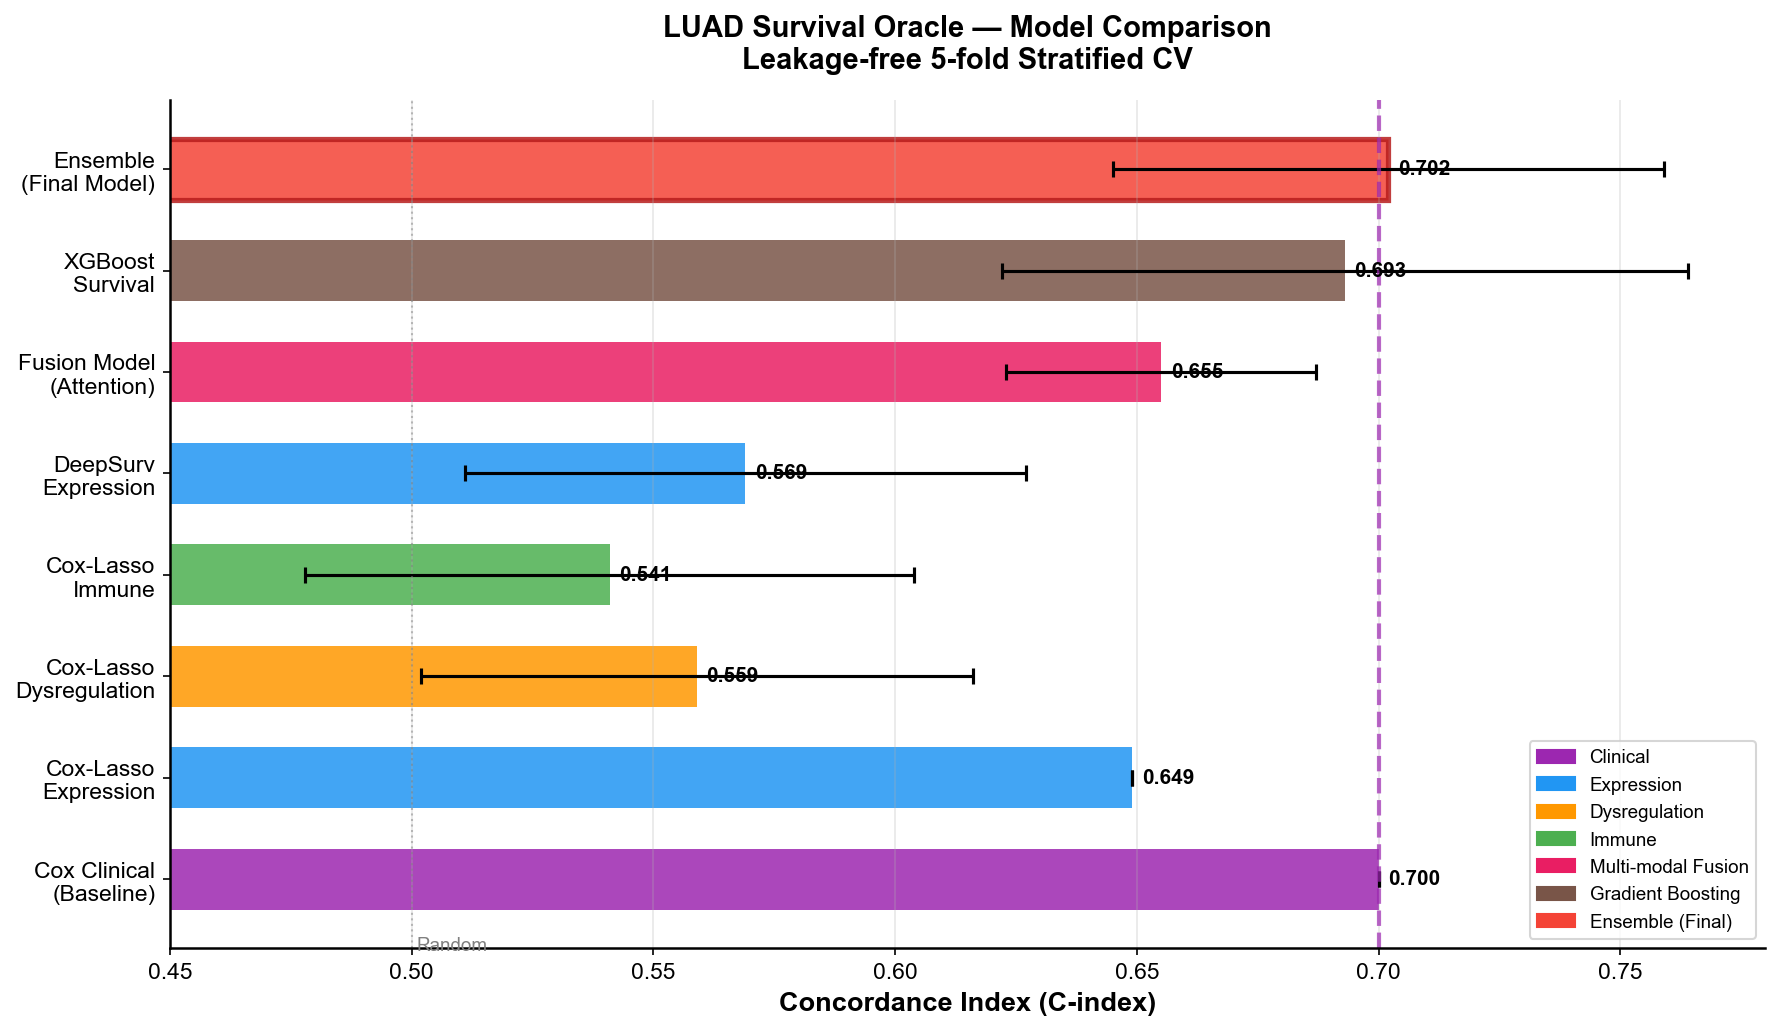

Saved: outputs/figures/01_model_comparison.png ✅


In [2]:
fig, ax = plt.subplots(figsize=(12, 7))

models = [
    'Cox Clinical\n(Baseline)',
    'Cox-Lasso\nExpression',
    'Cox-Lasso\nDysregulation',
    'Cox-Lasso\nImmune',
    'DeepSurv\nExpression',
    'Fusion Model\n(Attention)',
    'XGBoost\nSurvival',
    'Ensemble\n(Final Model)',
]

cindex = [0.700, 0.649, 0.559, 0.541, 0.569, 0.655, 0.693, 0.702]
errors = [0.000, 0.000, 0.057, 0.063, 0.058, 0.032, 0.071, 0.057]

colors = [
    '#9C27B0',  # clinical — purple
    '#2196F3',  # expression — blue
    '#FF9800',  # dysregulation — orange
    '#4CAF50',  # immune — green
    '#2196F3',  # deepsurv — blue
    '#E91E63',  # fusion — pink
    '#795548',  # xgboost — brown
    '#F44336',  # ensemble — red
]

bars = ax.barh(models, cindex, xerr=errors, 
               color=colors, alpha=0.85,
               error_kw={'linewidth': 1.5, 'capsize': 4, 'capthick': 1.5},
               height=0.6)

# Clinical baseline line
ax.axvline(x=0.700, color='#9C27B0', linestyle='--', 
           linewidth=2, alpha=0.7, label='Clinical baseline (0.700)')

# Annotate bars with values
for i, (bar, ci) in enumerate(zip(bars, cindex)):
    ax.text(ci + 0.002, bar.get_y() + bar.get_height()/2,
            f'{ci:.3f}', va='center', fontsize=10, fontweight='bold')

# Highlight final model
bars[-1].set_edgecolor('#B71C1C')
bars[-1].set_linewidth(2.5)

ax.set_xlabel('Concordance Index (C-index)', fontsize=13, fontweight='bold')
ax.set_title('LUAD Survival Oracle — Model Comparison\nLeakage-free 5-fold Stratified CV',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0.45, 0.78)
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.text(0.501, -0.7, 'Random', color='gray', fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Stream legend
legend_elements = [
    mpatches.Patch(color='#9C27B0', label='Clinical'),
    mpatches.Patch(color='#2196F3', label='Expression'),
    mpatches.Patch(color='#FF9800', label='Dysregulation'),
    mpatches.Patch(color='#4CAF50', label='Immune'),
    mpatches.Patch(color='#E91E63', label='Multi-modal Fusion'),
    mpatches.Patch(color='#795548', label='Gradient Boosting'),
    mpatches.Patch(color='#F44336', label='Ensemble (Final)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{base}/outputs/figures/01_model_comparison.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/01_model_comparison.png ✅")

High risk patients: 239
Low risk patients:  239
Log-rank p-value: 6.69e-39


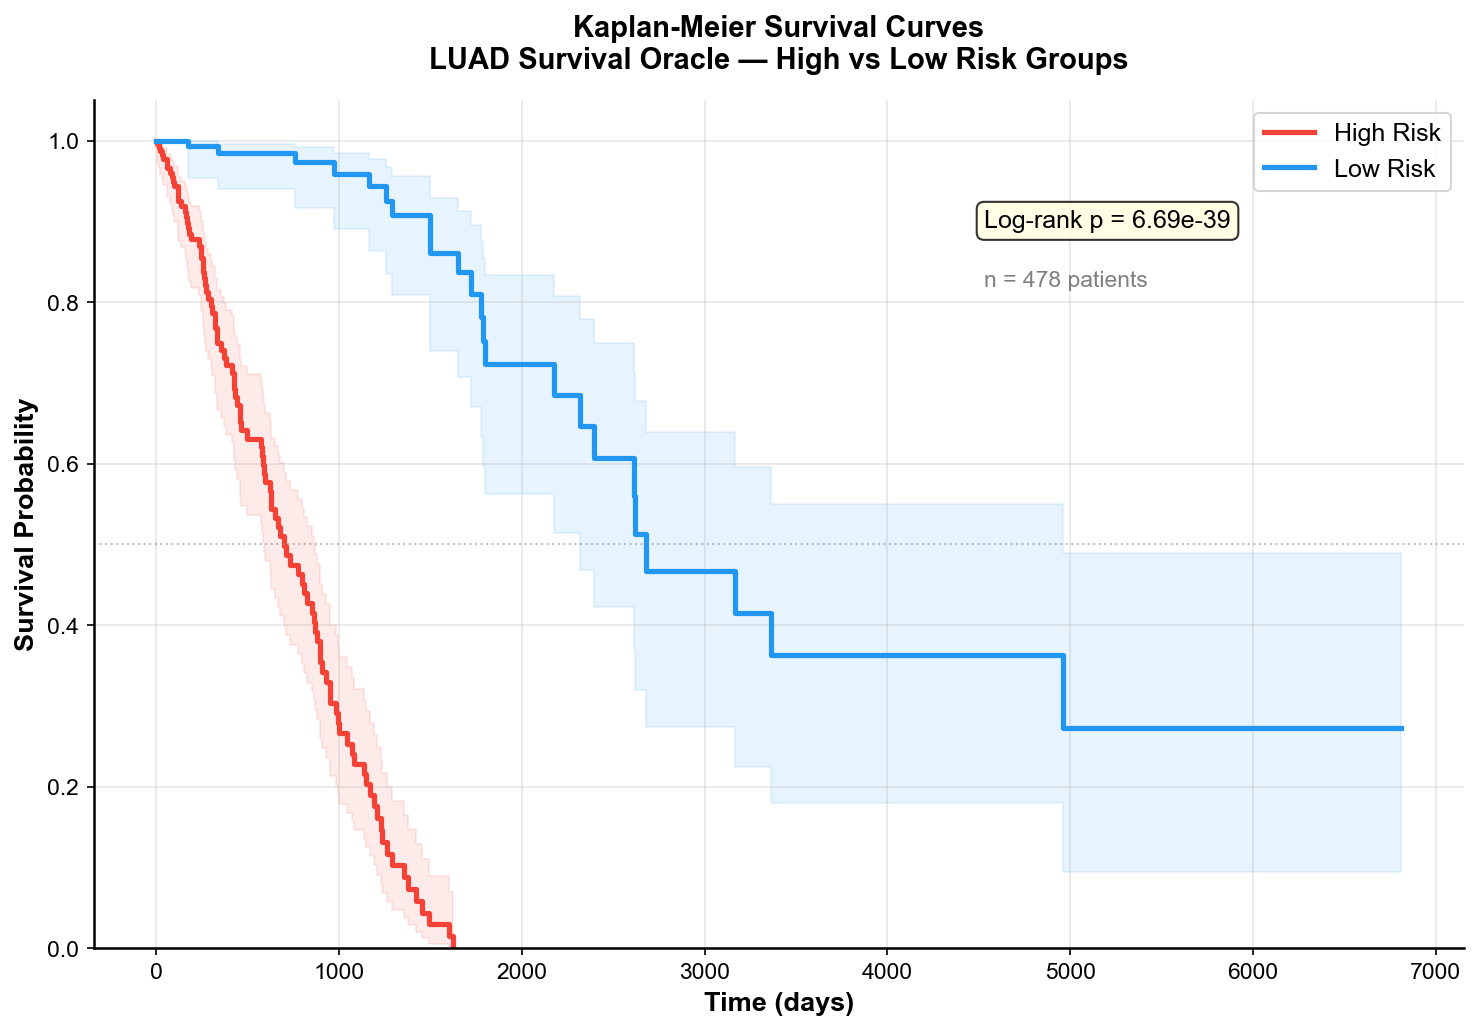

Saved: outputs/figures/02_kaplan_meier.png ✅


In [3]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter

# Load data
expr     = pd.read_csv(f'{base}/data/processed/expression_matrix.csv', index_col=0)
dysreg   = pd.read_csv(f'{base}/data/processed/dysregulation_scores.csv', index_col=0)
immune   = pd.read_csv(f'{base}/data/processed/immune_features_cibersort.csv', index_col=0)
clinical = pd.read_csv(f'{base}/data/processed/clinical_survival.csv', index_col=0)

common   = expr.index.intersection(dysreg.index).intersection(
           immune.index).intersection(clinical.index)
expr     = expr.loc[common]
dysreg   = dysreg.loc[common]
immune   = immune.loc[common]
clinical = clinical.loc[common]

age_tr    = clinical[['age']].copy()
gender_tr = (clinical['gender'] == 'male').astype(float).to_frame()
stage_tr  = pd.get_dummies(clinical['stage_group'], prefix='stage')
stage_tr  = stage_tr.drop(columns=['stage_Stage I'], errors='ignore')
clinical_features = pd.concat([age_tr, gender_tr, stage_tr], 
                               axis=1).astype(float).fillna(0)

y = np.array(
    [(bool(e), t) for e, t in zip(clinical['event'], clinical['survival_time'])],
    dtype=[('event', bool), ('time', float)])

# Load Lasso genes
cox_lasso   = pickle.load(open(f'{base}/models/cox_lasso_expression.pkl', 'rb'))
gene_list   = json.load(open(f'{base}/models/gene_list.json'))
coefs       = cox_lasso.coef_[:, 0]
lasso_genes = [g for g, s in zip(gene_list, coefs != 0) if s]

# Build feature matrix (same as NB11c)
expr_lasso = expr[lasso_genes].copy()
expr_lasso.columns = [f"{g}_expr" for g in lasso_genes]

# Cox dysreg selection on full data
times  = y['time']; events = y['event']
cox_pvals_d = {}
for gene in dysreg.columns:
    try:
        df_tmp = pd.DataFrame({'T': times, 'E': events, 'gene': dysreg[gene].values})
        cph = CoxPHFitter()
        cph.fit(df_tmp, duration_col='T', event_col='E', show_progress=False)
        cox_pvals_d[gene] = cph.summary['p'].values[0]
    except:
        cox_pvals_d[gene] = 1.0
top_dysreg = list(pd.Series(cox_pvals_d).nsmallest(20).index)

dysreg_sel = dysreg[top_dysreg].copy()
dysreg_sel.columns = [f"{g}_dysreg" for g in top_dysreg]

interactions = pd.DataFrame({
    'stageIII_x_M2':   (clinical_features['stage_Stage III'] * immune['Macrophages M2']).values,
    'stageIV_x_CD8':   (clinical_features['stage_Stage IV']  * immune['T cells CD8']).values,
    'age_x_stageIII':  (clinical_features['age'] * clinical_features['stage_Stage III']).values,
    'stageIII_x_Treg': (clinical_features['stage_Stage III'] * immune['T cells regulatory (Tregs)']).values,
    'M2_x_CD8':        (immune['Macrophages M2'] * immune['T cells CD8']).values,
}, index=expr.index)

X = pd.concat([expr_lasso, dysreg_sel, immune, clinical_features, interactions], axis=1).fillna(0)

scaler  = StandardScaler()
X_s     = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Train final model on all data
model_final = GradientBoostingSurvivalAnalysis(
    n_estimators=300, learning_rate=0.05, max_depth=2,
    min_samples_split=20, min_samples_leaf=10,
    subsample=0.8, random_state=42)
model_final.fit(X_s, y)

# Get risk scores
risk_scores = model_final.predict(X_s)

# Split into high/low risk by median
median_risk = np.median(risk_scores)
high_risk   = risk_scores >= median_risk
low_risk    = risk_scores < median_risk

print(f"High risk patients: {high_risk.sum()}")
print(f"Low risk patients:  {low_risk.sum()}")

# Log-rank test
results = logrank_test(
    y['time'][high_risk], y['time'][low_risk],
    y['event'][high_risk], y['event'][low_risk])
print(f"Log-rank p-value: {results.p_value:.2e}")

# Plot KM curves
fig, ax = plt.subplots(figsize=(10, 7))

kmf_high = KaplanMeierFitter()
kmf_low  = KaplanMeierFitter()

kmf_high.fit(y['time'][high_risk], y['event'][high_risk], label='High Risk')
kmf_low.fit(y['time'][low_risk],  y['event'][low_risk],  label='Low Risk')

kmf_high.plot_survival_function(ax=ax, color='#F44336', linewidth=2.5,
                                  ci_show=True, ci_alpha=0.1)
kmf_low.plot_survival_function(ax=ax,  color='#2196F3', linewidth=2.5,
                                 ci_show=True, ci_alpha=0.1)

ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('Time (days)', fontsize=13, fontweight='bold')
ax.set_ylabel('Survival Probability', fontsize=13, fontweight='bold')
ax.set_title('Kaplan-Meier Survival Curves\nLUAD Survival Oracle — High vs Low Risk Groups',
             fontsize=14, fontweight='bold', pad=15)

# Add p-value
ax.text(0.65, 0.85, f'Log-rank p = {results.p_value:.2e}',
        transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.text(0.65, 0.78, f'n = {len(y)} patients',
        transform=ax.transAxes, fontsize=11, color='gray')

ax.set_ylim(0, 1.05)
ax.legend(fontsize=12, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{base}/outputs/figures/02_kaplan_meier.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/02_kaplan_meier.png ✅")

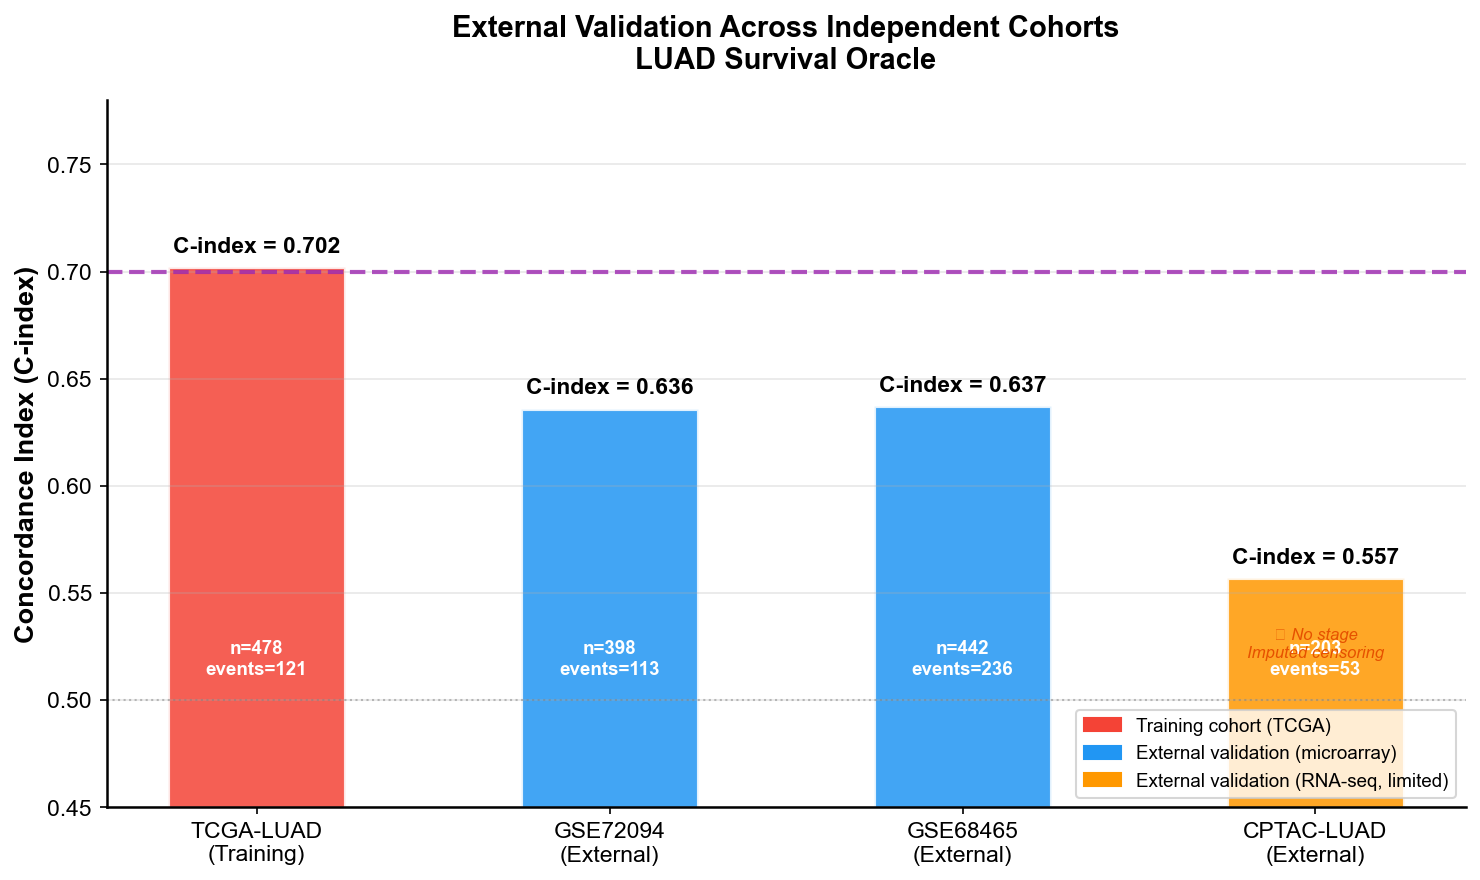

Saved: outputs/figures/03_external_validation.png ✅


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

cohorts  = ['TCGA-LUAD\n(Training)', 'GSE72094\n(External)', 
            'GSE68465\n(External)', 'CPTAC-LUAD\n(External)']
cindex   = [0.702, 0.636, 0.637, 0.557]
n_pats   = [478, 398, 442, 203]
n_events = [121, 113, 236, 53]
colors   = ['#F44336', '#2196F3', '#2196F3', '#FF9800']
alphas   = [1.0, 0.85, 0.85, 0.6]

bars = ax.bar(cohorts, cindex, color=colors, 
              alpha=0.85, width=0.5, edgecolor='white', linewidth=1.5)

# Clinical baseline line
ax.axhline(y=0.700, color='#9C27B0', linestyle='--',
           linewidth=2, alpha=0.8, label='Clinical baseline (0.700)')

# Random line
ax.axhline(y=0.5, color='gray', linestyle=':',
           linewidth=1, alpha=0.5, label='Random (0.500)')

# Annotate bars
for bar, ci, n, e in zip(bars, cindex, n_pats, n_events):
    ax.text(bar.get_x() + bar.get_width()/2, ci + 0.005,
            f'C-index = {ci:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, 0.51,
            f'n={n}\nevents={e}', ha='center', va='bottom',
            fontsize=9, color='white', fontweight='bold')

# CPTAC note
ax.text(3, 0.52, '⚠ No stage\nImputed censoring',
        ha='center', fontsize=8, color='#E65100',
        style='italic')

ax.set_ylabel('Concordance Index (C-index)', fontsize=13, fontweight='bold')
ax.set_title('External Validation Across Independent Cohorts\nLUAD Survival Oracle',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0.45, 0.78)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Legend for colors
legend_elements = [
    mpatches.Patch(color='#F44336', label='Training cohort (TCGA)'),
    mpatches.Patch(color='#2196F3', label='External validation (microarray)'),
    mpatches.Patch(color='#FF9800', label='External validation (RNA-seq, limited)'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(f'{base}/outputs/figures/03_external_validation.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/03_external_validation.png ✅")

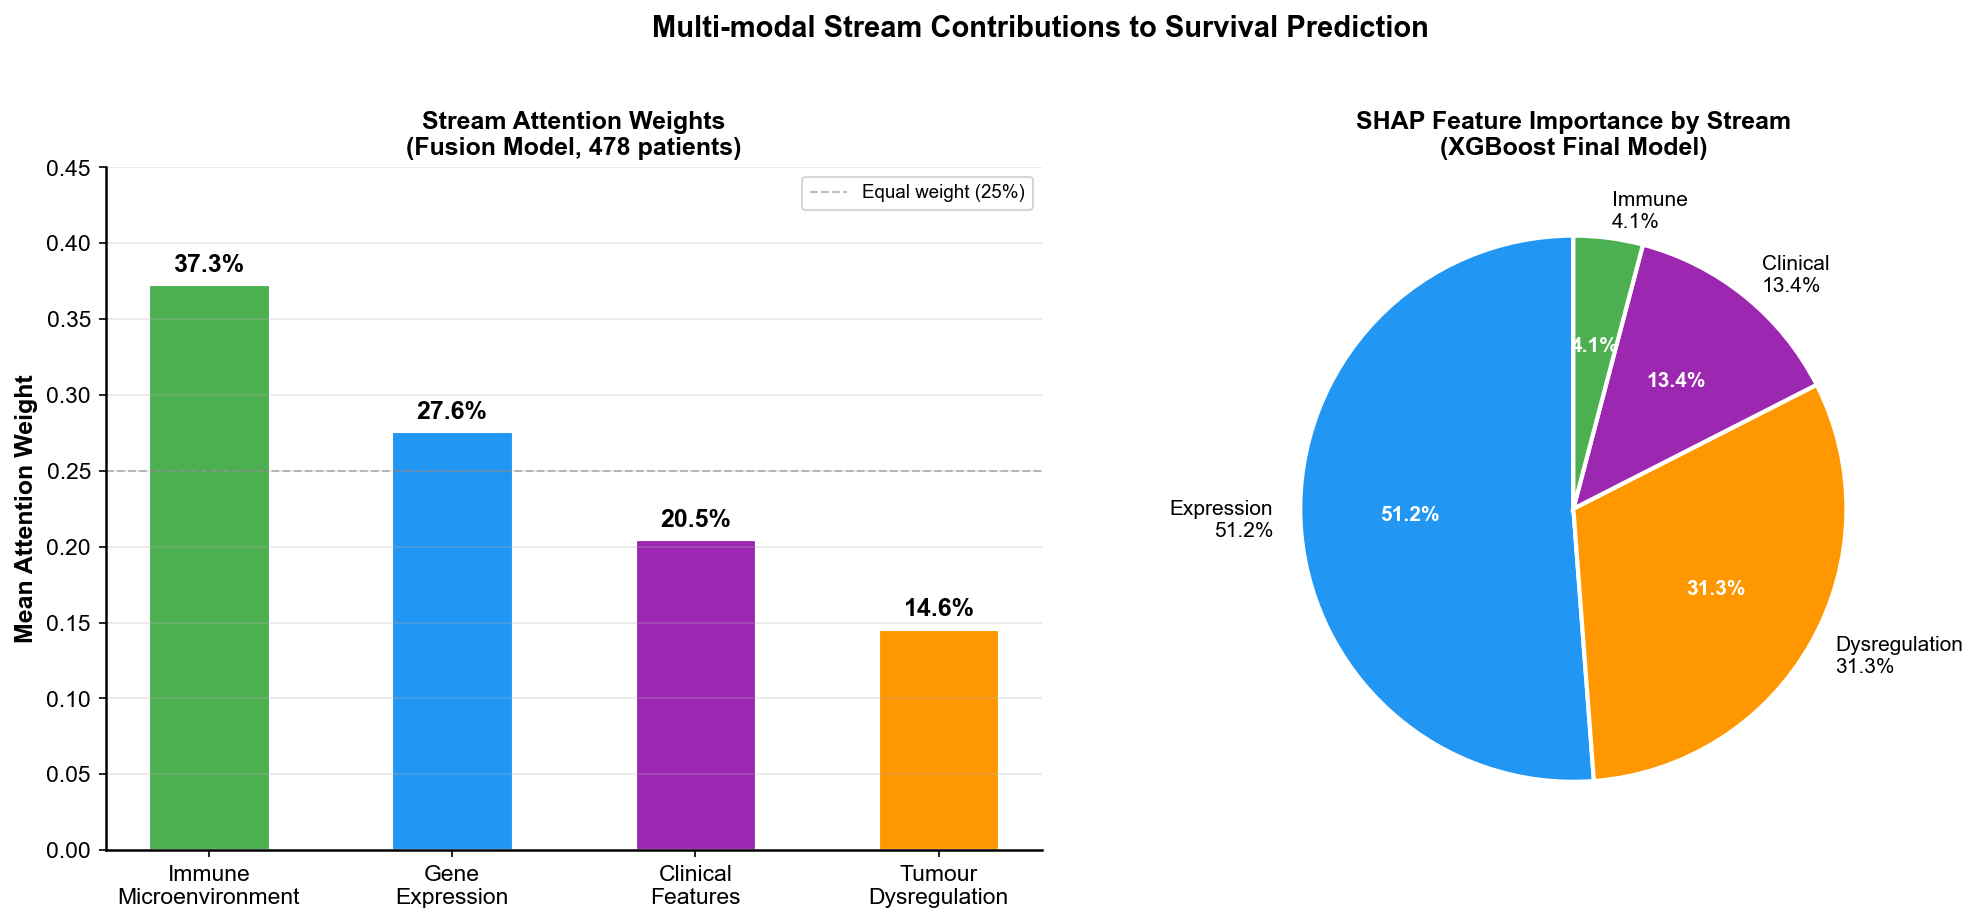

Saved: outputs/figures/04_stream_contributions.png ✅


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Stream attention weights bar chart ──────────────────────
streams  = ['Immune\nMicroenvironment', 'Gene\nExpression', 
            'Clinical\nFeatures', 'Tumour\nDysregulation']
weights  = [0.373, 0.276, 0.205, 0.146]
colors_s = ['#4CAF50', '#2196F3', '#9C27B0', '#FF9800']

bars = axes[0].bar(streams, weights, color=colors_s, 
                    width=0.5, edgecolor='white', linewidth=1.5)

for bar, w in zip(bars, weights):
    axes[0].text(bar.get_x() + bar.get_width()/2, w + 0.005,
                 f'{w*100:.1f}%', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

axes[0].set_ylabel('Mean Attention Weight', fontsize=12, fontweight='bold')
axes[0].set_title('Stream Attention Weights\n(Fusion Model, 478 patients)',
                   fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 0.45)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0.25, color='gray', linestyle='--', 
                alpha=0.5, linewidth=1, label='Equal weight (25%)')
axes[0].legend(fontsize=9)

# ── Right: SHAP stream contribution pie ──────────────────────────
shap_streams = ['Expression\n51.2%', 'Dysregulation\n31.3%', 
                'Clinical\n13.4%', 'Immune\n4.1%']
shap_values  = [51.2, 31.3, 13.4, 4.1]
colors_shap  = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50']

wedges, texts, autotexts = axes[1].pie(
    shap_values,
    labels=shap_streams,
    colors=colors_shap,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

axes[1].set_title('SHAP Feature Importance by Stream\n(XGBoost Final Model)',
                   fontsize=12, fontweight='bold')

plt.suptitle('Multi-modal Stream Contributions to Survival Prediction',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(f'{base}/outputs/figures/04_stream_contributions.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/04_stream_contributions.png ✅")

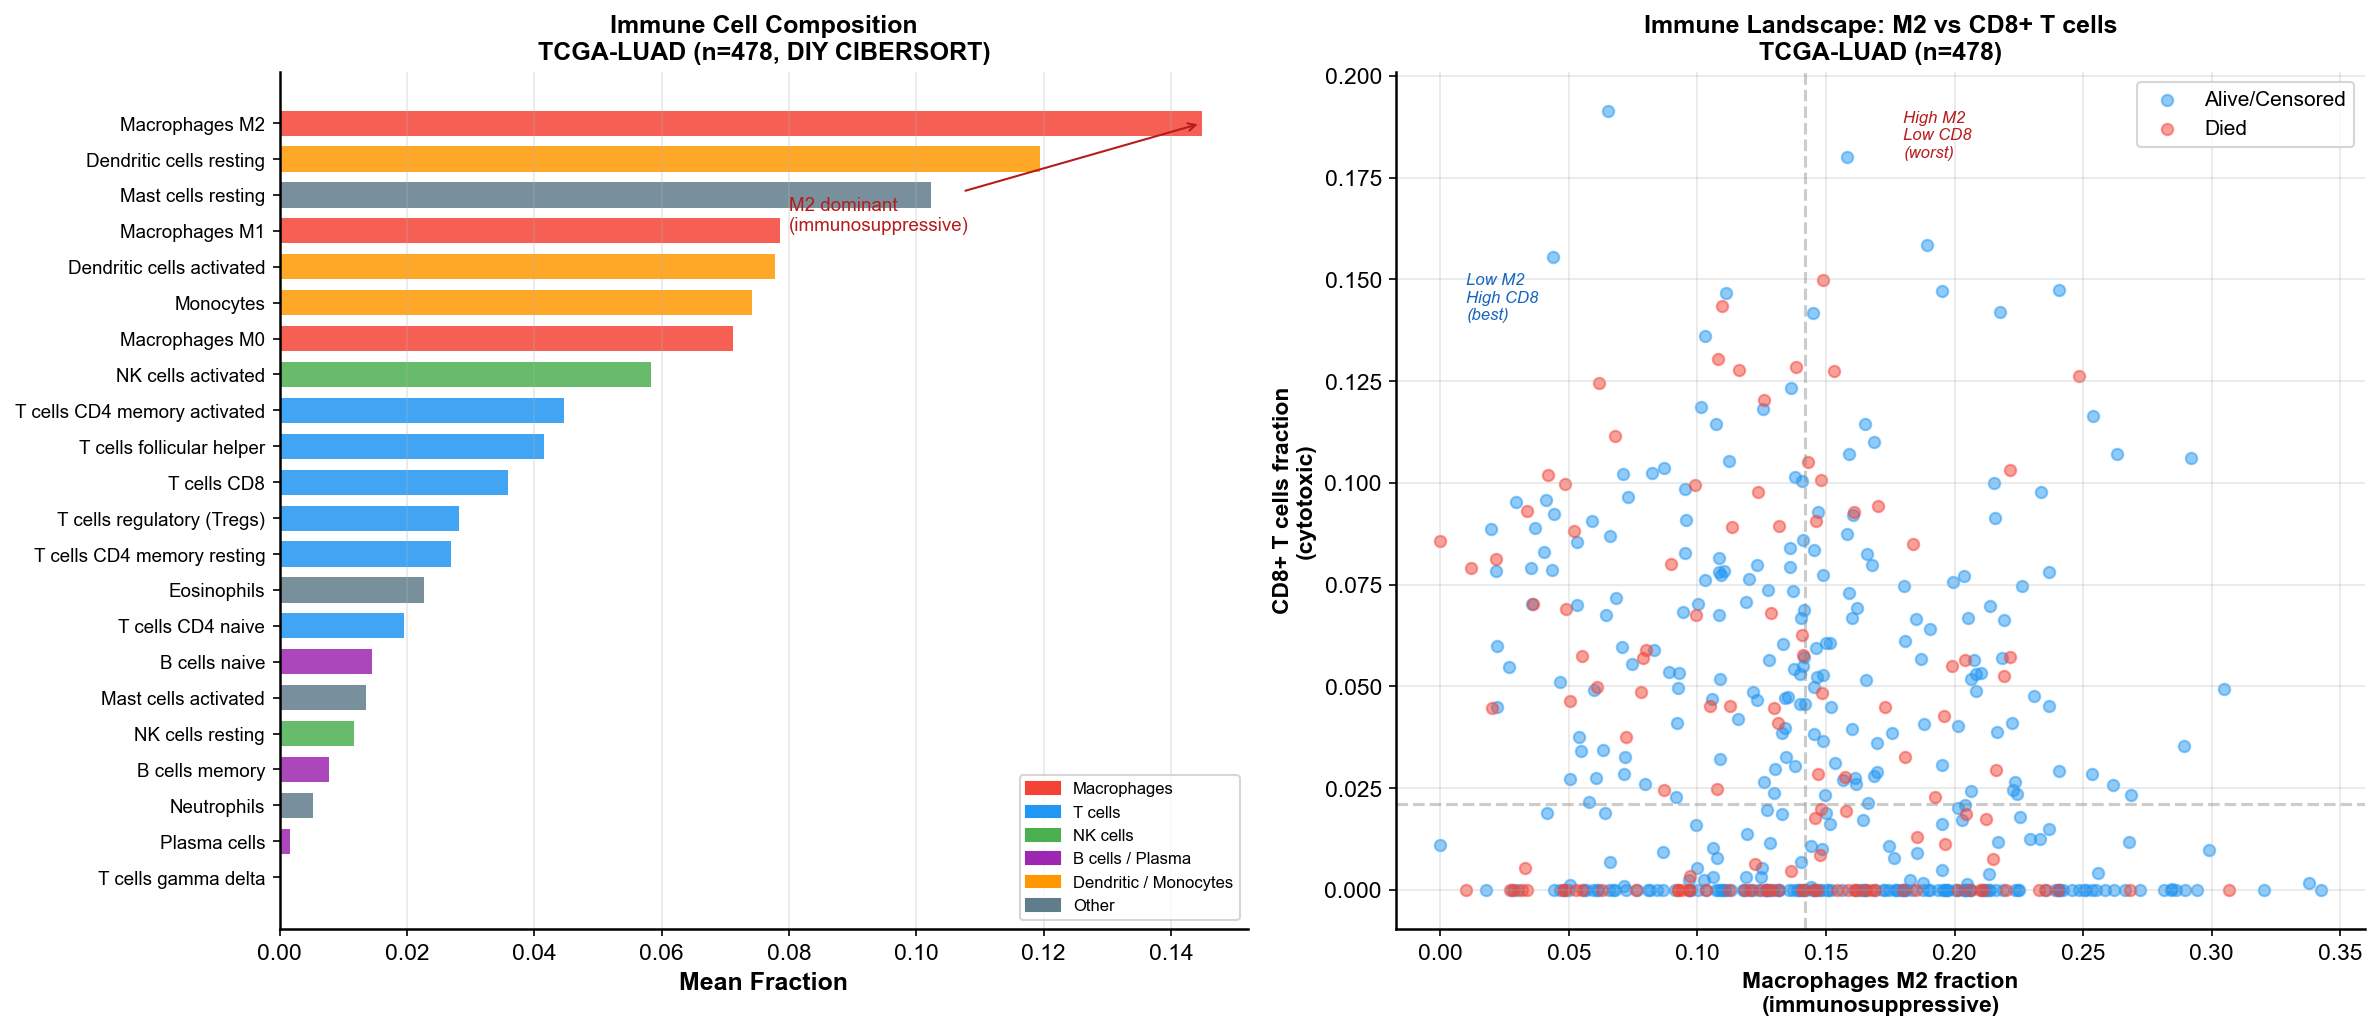

Saved: outputs/figures/05_immune_landscape.png ✅


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Mean immune fractions across 478 TCGA patients
immune_data = pd.read_csv(f'{base}/data/processed/immune_features_cibersort.csv', index_col=0)
mean_fracs  = immune_data.mean().sort_values(ascending=True)

colors_immune = []
for cell in mean_fracs.index:
    if 'Macrophage' in cell:
        colors_immune.append('#F44336')
    elif 'T cells' in cell:
        colors_immune.append('#2196F3')
    elif 'NK' in cell:
        colors_immune.append('#4CAF50')
    elif 'B cells' in cell or 'Plasma' in cell:
        colors_immune.append('#9C27B0')
    elif 'Dendritic' in cell or 'Monocyte' in cell:
        colors_immune.append('#FF9800')
    else:
        colors_immune.append('#607D8B')

bars = axes[0].barh(range(len(mean_fracs)), mean_fracs.values,
                     color=colors_immune, alpha=0.85, height=0.7)

axes[0].set_yticks(range(len(mean_fracs)))
axes[0].set_yticklabels(mean_fracs.index, fontsize=9)
axes[0].set_xlabel('Mean Fraction', fontsize=12, fontweight='bold')
axes[0].set_title('Immune Cell Composition\nTCGA-LUAD (n=478, DIY CIBERSORT)',
                   fontsize=12, fontweight='bold')

# Annotate M2
m2_idx = list(mean_fracs.index).index('Macrophages M2')
axes[0].annotate('M2 dominant\n(immunosuppressive)',
                  xy=(mean_fracs['Macrophages M2'], m2_idx),
                  xytext=(0.08, m2_idx - 3),
                  fontsize=9, color='#B71C1C',
                  arrowprops=dict(arrowstyle='->', color='#B71C1C'))

legend_elements = [
    mpatches.Patch(color='#F44336', label='Macrophages'),
    mpatches.Patch(color='#2196F3', label='T cells'),
    mpatches.Patch(color='#4CAF50', label='NK cells'),
    mpatches.Patch(color='#9C27B0', label='B cells / Plasma'),
    mpatches.Patch(color='#FF9800', label='Dendritic / Monocytes'),
    mpatches.Patch(color='#607D8B', label='Other'),
]
axes[0].legend(handles=legend_elements, fontsize=8, loc='lower right')
axes[0].grid(axis='x', alpha=0.3)

# ── Right: M2 vs CD8 scatter (immunosuppression axis) ────────────
m2   = immune_data['Macrophages M2']
cd8  = immune_data['T cells CD8']
survived = clinical.loc[immune_data.index, 'event'] == 0

axes[1].scatter(m2[survived],  cd8[survived],  
                alpha=0.5, s=30, color='#2196F3', label='Alive/Censored')
axes[1].scatter(m2[~survived], cd8[~survived], 
                alpha=0.5, s=30, color='#F44336', label='Died')

axes[1].set_xlabel('Macrophages M2 fraction\n(immunosuppressive)', 
                    fontsize=11, fontweight='bold')
axes[1].set_ylabel('CD8+ T cells fraction\n(cytotoxic)', 
                    fontsize=11, fontweight='bold')
axes[1].set_title('Immune Landscape: M2 vs CD8+ T cells\nTCGA-LUAD (n=478)',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# Add quadrant annotations
axes[1].axvline(x=m2.median(), color='gray', linestyle='--', alpha=0.4)
axes[1].axhline(y=cd8.median(), color='gray', linestyle='--', alpha=0.4)
axes[1].text(0.18, 0.18, 'High M2\nLow CD8\n(worst)', 
             fontsize=8, color='#B71C1C', style='italic')
axes[1].text(0.01, 0.14, 'Low M2\nHigh CD8\n(best)', 
             fontsize=8, color='#1565C0', style='italic')

plt.tight_layout()
plt.savefig(f'{base}/outputs/figures/05_immune_landscape.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/05_immune_landscape.png ✅")

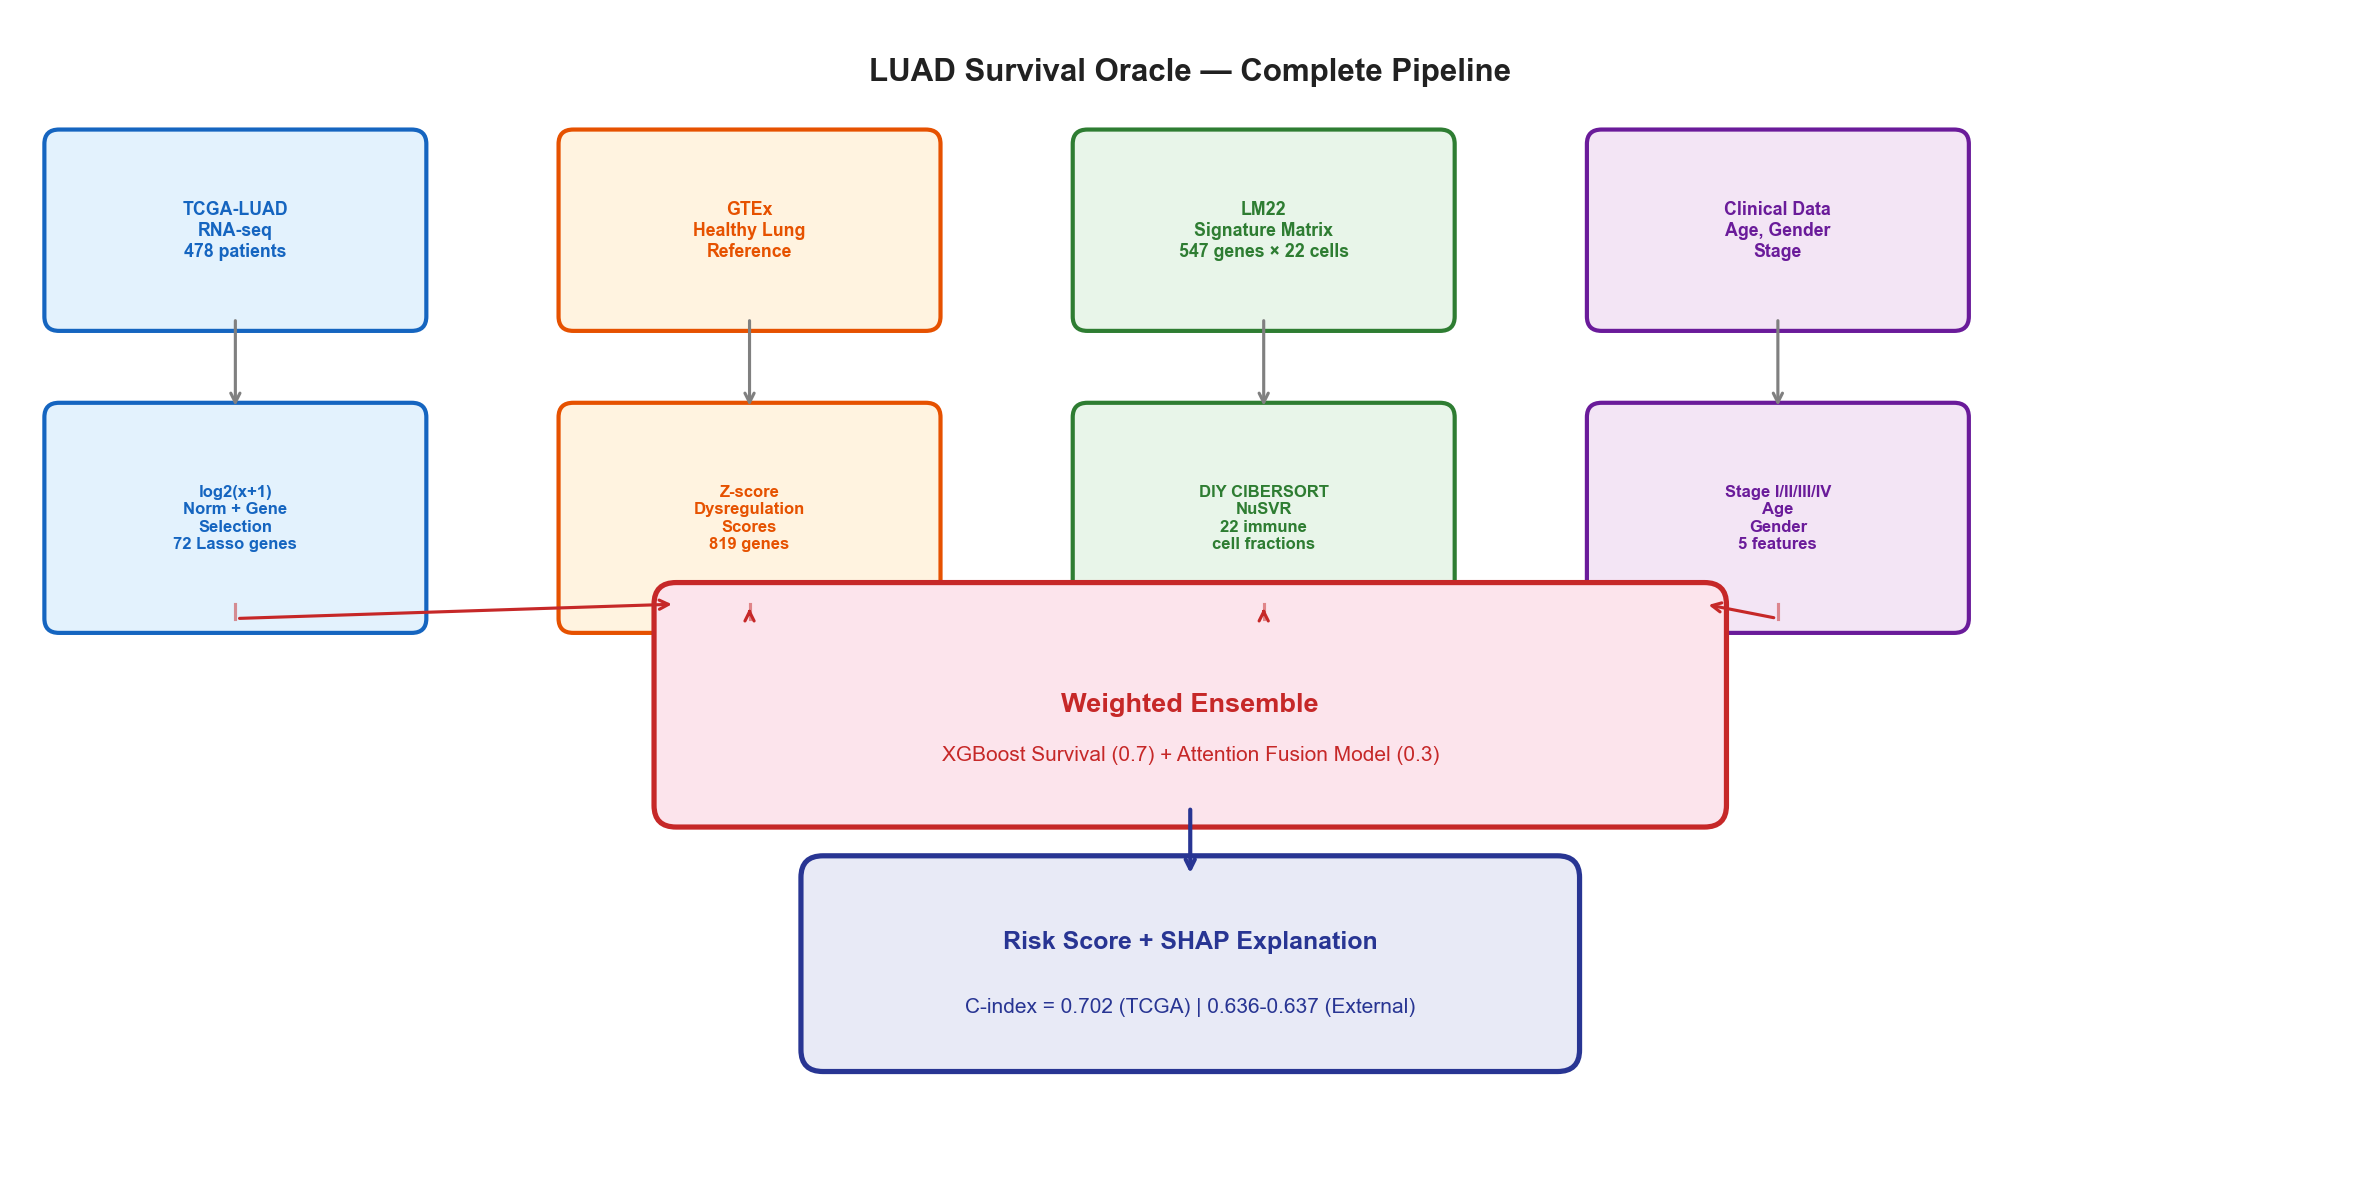

Saved: outputs/figures/06_pipeline_overview.png ✅


In [7]:
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis('off')

# ── Data sources (top row) ────────────────────────────────────────
sources = [
    (1.5, 6.5, 'TCGA-LUAD\nRNA-seq\n478 patients', '#E3F2FD', '#1565C0'),
    (5.0, 6.5, 'GTEx\nHealthy Lung\nReference', '#FFF3E0', '#E65100'),
    (8.5, 6.5, 'LM22\nSignature Matrix\n547 genes × 22 cells', '#E8F5E9', '#2E7D32'),
    (12.0, 6.5, 'Clinical Data\nAge, Gender\nStage', '#F3E5F5', '#6A1B9A'),
]

for x, y, text, fc, ec in sources:
    box = mpatches.FancyBboxPatch((x-1.2, y-0.6), 2.4, 1.2,
                                   boxstyle='round,pad=0.1',
                                   facecolor=fc, edgecolor=ec, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=8.5,
            fontweight='bold', color=ec)

# ── Processing (middle row) ───────────────────────────────────────
processing = [
    (1.5, 4.5, 'log2(x+1)\nNorm + Gene\nSelection\n72 Lasso genes', '#E3F2FD', '#1565C0'),
    (5.0, 4.5, 'Z-score\nDysregulation\nScores\n819 genes', '#FFF3E0', '#E65100'),
    (8.5, 4.5, 'DIY CIBERSORT\nNuSVR\n22 immune\ncell fractions', '#E8F5E9', '#2E7D32'),
    (12.0, 4.5, 'Stage I/II/III/IV\nAge\nGender\n5 features', '#F3E5F5', '#6A1B9A'),
]

for x, y, text, fc, ec in processing:
    box = mpatches.FancyBboxPatch((x-1.2, y-0.7), 2.4, 1.4,
                                   boxstyle='round,pad=0.1',
                                   facecolor=fc, edgecolor=ec, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=8,
            fontweight='bold', color=ec)

# Arrows from sources to processing
for x in [1.5, 5.0, 8.5, 12.0]:
    ax.annotate('', xy=(x, 5.25), xytext=(x, 5.9),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# ── Fusion box ────────────────────────────────────────────────────
fusion_box = mpatches.FancyBboxPatch((4.5, 2.5), 7, 1.4,
                                      boxstyle='round,pad=0.15',
                                      facecolor='#FCE4EC', edgecolor='#C62828', linewidth=2.5)
ax.add_patch(fusion_box)
ax.text(8, 3.2, 'Weighted Ensemble', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#C62828')
ax.text(8, 2.85, 'XGBoost Survival (0.7) + Attention Fusion Model (0.3)',
        ha='center', va='center', fontsize=10, color='#C62828')

# Arrows from processing to fusion
for x in [1.5, 5.0, 8.5, 12.0]:
    ax.annotate('', xy=(max(4.5, min(11.5, x)), 3.9),
                xytext=(x, 3.8),
                arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.5))
for x in [1.5, 5.0, 8.5, 12.0]:
    ax.plot([x, x], [3.8, 3.15+0.75], color='#C62828', lw=1.5, alpha=0.5)

# ── Output box ───────────────────────────────────────────────────
output_box = mpatches.FancyBboxPatch((5.5, 0.8), 5, 1.2,
                                      boxstyle='round,pad=0.15',
                                      facecolor='#E8EAF6', edgecolor='#283593', linewidth=2.5)
ax.add_patch(output_box)
ax.text(8, 1.55, 'Risk Score + SHAP Explanation',
        ha='center', va='center', fontsize=12, fontweight='bold', color='#283593')
ax.text(8, 1.1, 'C-index = 0.702 (TCGA) | 0.636-0.637 (External)',
        ha='center', va='center', fontsize=10, color='#283593')

ax.annotate('', xy=(8, 2.0), xytext=(8, 2.5),
            arrowprops=dict(arrowstyle='->', color='#283593', lw=2))

# Title
ax.text(8, 7.6, 'LUAD Survival Oracle — Complete Pipeline',
        ha='center', va='center', fontsize=15, fontweight='bold', color='#212121')

plt.tight_layout()
plt.savefig(f'{base}/outputs/figures/06_pipeline_overview.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/06_pipeline_overview.png ✅")

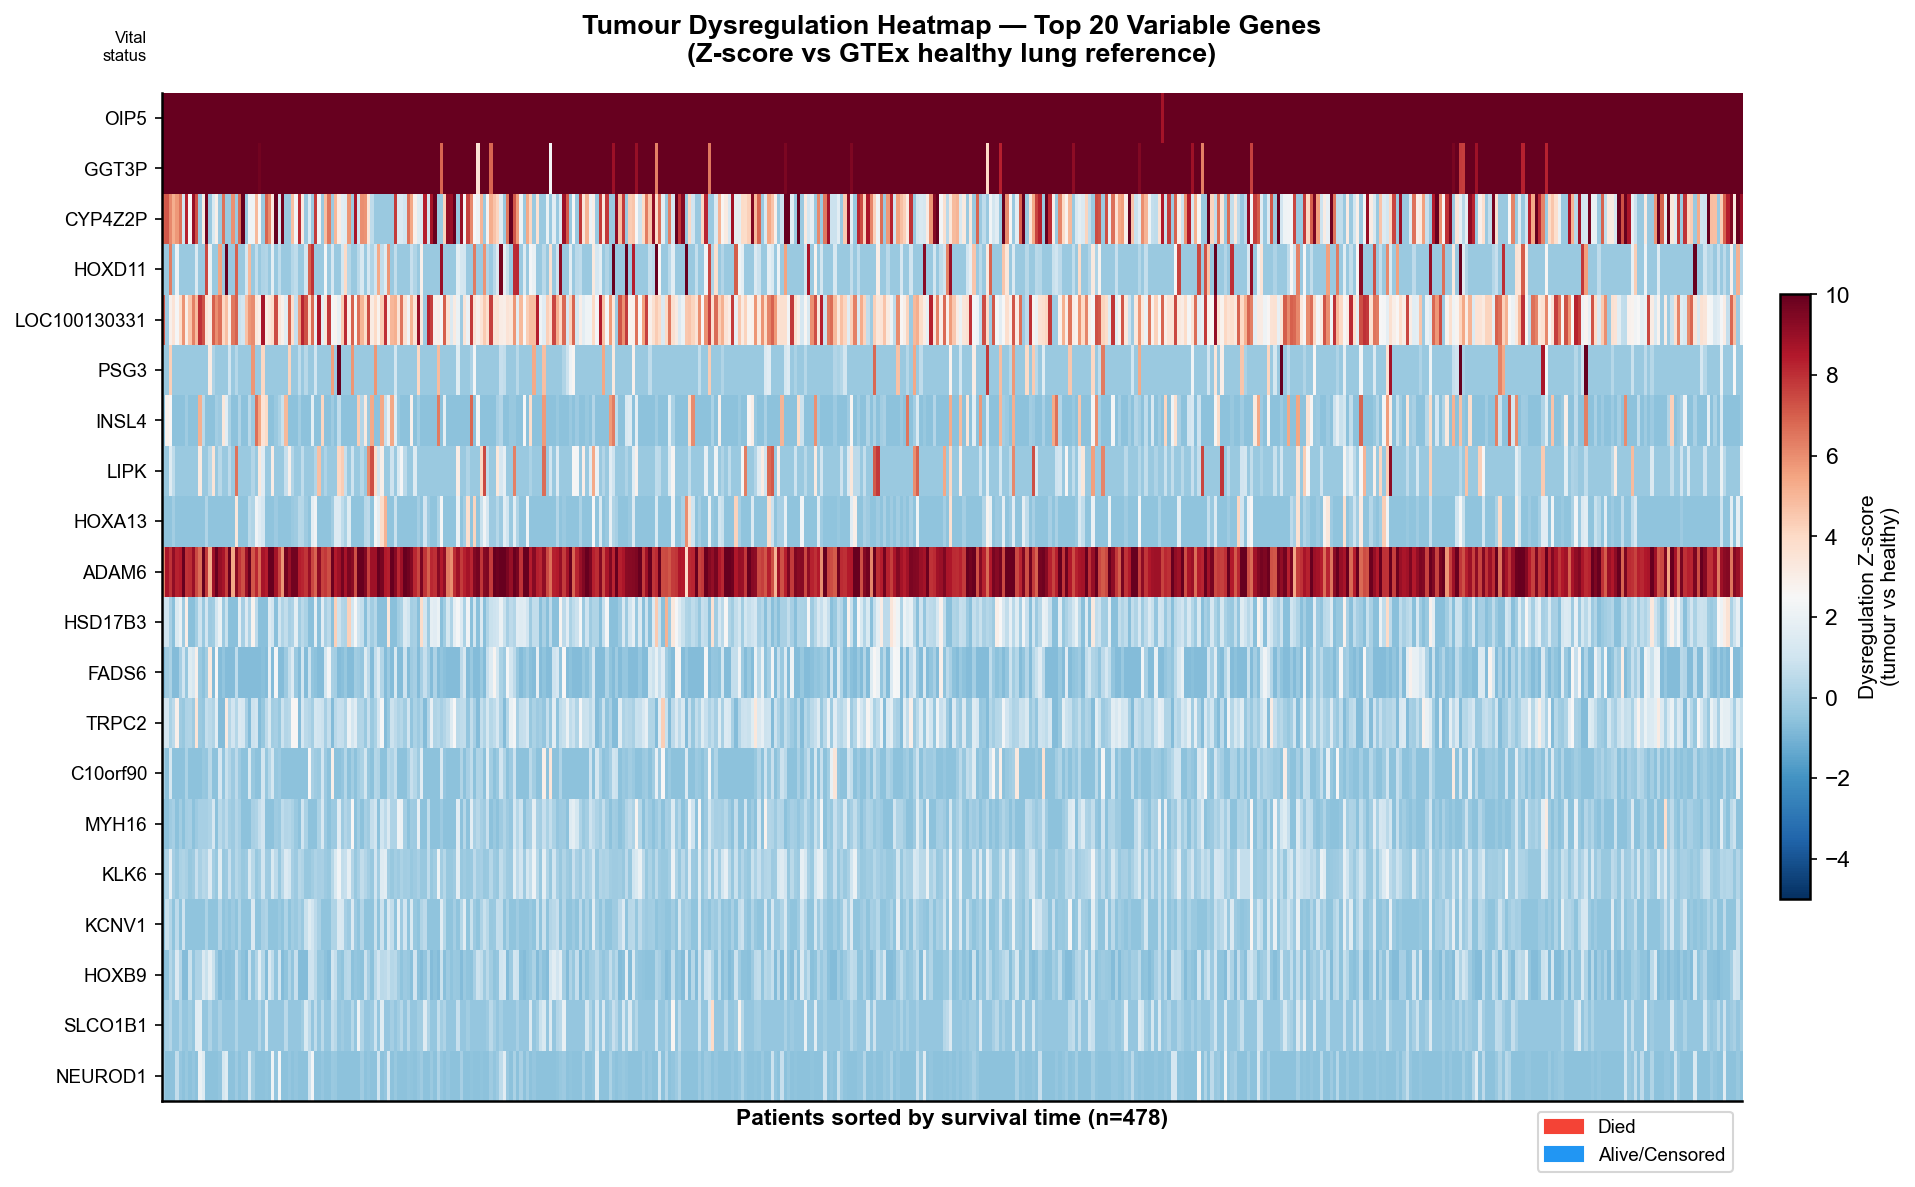

Saved: outputs/figures/07_dysregulation_heatmap.png ✅


In [8]:
# Load dysregulation scores
dysreg = pd.read_csv(f'{base}/data/processed/dysregulation_scores.csv', index_col=0)
clinical = pd.read_csv(f'{base}/data/processed/clinical_survival.csv', index_col=0)

# Align
common = dysreg.index.intersection(clinical.index)
dysreg = dysreg.loc[common]
clinical = clinical.loc[common]

# Top 20 most variable dysregulation genes
top20_var = dysreg.var(axis=0).nlargest(20).index
dysreg_top20 = dysreg[top20_var]

# Sort patients by survival time
clinical_sorted = clinical.sort_values('survival_time')
dysreg_sorted   = dysreg_top20.loc[clinical_sorted.index]

# Clip extreme values for visualization
dysreg_clipped = dysreg_sorted.clip(-5, 15)

fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(dysreg_clipped.T.values, 
               aspect='auto', cmap='RdBu_r',
               vmin=-5, vmax=10)

ax.set_xticks([])
ax.set_yticks(range(len(top20_var)))
ax.set_yticklabels(top20_var, fontsize=9)
ax.set_xlabel(f'Patients sorted by survival time (n={len(dysreg_sorted)})', 
               fontsize=11, fontweight='bold')
ax.set_title('Tumour Dysregulation Heatmap — Top 20 Variable Genes\n(Z-score vs GTEx healthy lung reference)',
             fontsize=13, fontweight='bold', pad=15)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Dysregulation Z-score\n(tumour vs healthy)', fontsize=10)

# Add survival indicator bar at bottom
ax.set_xlim(-0.5, len(dysreg_sorted) - 0.5)

# Dead/alive bar
event_colors = ['#F44336' if e else '#2196F3' 
                for e in clinical_sorted['event']]
for i, c in enumerate(event_colors):
    ax.add_patch(mpatches.Rectangle((i-0.5, -1.8), 1, 0.8,
                                     facecolor=c, alpha=0.7))

ax.text(-5, -1.4, 'Vital\nstatus', fontsize=8, ha='right', va='center')

legend_elements = [
    mpatches.Patch(color='#F44336', label='Died'),
    mpatches.Patch(color='#2196F3', label='Alive/Censored'),
]
ax.legend(handles=legend_elements, fontsize=9, 
          loc='lower right', bbox_to_anchor=(1, -0.08))

plt.tight_layout()
plt.savefig(f'{base}/outputs/figures/07_dysregulation_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/07_dysregulation_heatmap.png ✅")